# Test Workflow — MSI Pipeline Validation

This notebook tests the `workflow.py` pipeline step by step, verifying that each function
in `msi.py` works correctly and produces the expected outputs.

We use **ketoprofen** (~1,400 molecules) as the test dataset because it's small enough
to run quickly but large enough to validate the full pipeline.

---

## Test Plan

| # | Test | What we verify |
|---|------|----------------|
| 1 | Imports & model loading | All dependencies available, model loads correctly |
| 2 | `generate_2d_vectors()` | CSV output has correct columns, no NaN, valid shape |
| 3 | `generate_300d_vectors()` | 300 numeric columns, same row count as 2D |
| 4 | `analyze_against_reference()` | All metrics computed, theta is float, ranges valid |
| 5 | Full `run_dataset_pipeline()` | End-to-end integration, timing, summary output |
| 6 | Output validation | Cross-check against original pipeline results |
| 7 | Clustering (K-Means) | Labels assigned, visualization generated |

---
## 1. Imports & Model Loading

In [1]:
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import Word2Vec

sns.set_theme(style='white', font_scale=1.1)

# Ensure msi.py is importable
SCRIPT_DIR = os.path.abspath('.')
if SCRIPT_DIR not in sys.path:
    sys.path.insert(0, SCRIPT_DIR)

print(f"Working directory: {os.getcwd()}")
print(f"Python path includes: {SCRIPT_DIR}")

Working directory: /Users/nose/Desktop/MMSI_Upgraded
Python path includes: /Users/nose/Desktop/MMSI_Upgraded


In [2]:
# Import MSI module functions
from msi import (
    generate_2d_vectors,
    generate_300d_vectors,
    analyze_against_reference,
    cluster_kmeans,
    compute_tanimoto_similarity,
    calculate_molecular_weight,
    mahalanobis_angle,
    mahalanobis_magnitude,
    PipelineMetrics,
    REGULARIZATION_LAMBDA,
    MORGAN_RADIUS,
    MORGAN_NBITS,
)

print("All MSI imports successful")
print(f"  REGULARIZATION_LAMBDA = {REGULARIZATION_LAMBDA}")
print(f"  MORGAN_RADIUS = {MORGAN_RADIUS}")
print(f"  MORGAN_NBITS = {MORGAN_NBITS}")

All MSI imports successful
  REGULARIZATION_LAMBDA = 1e-05
  MORGAN_RADIUS = 2
  MORGAN_NBITS = 2048


In [3]:
# Import workflow functions
from workflow import (
    run_dataset_pipeline,
    print_summary,
    DATASETS,
    DATA_DIR,
    OUTPUT_DIR,
    MODEL_PATH,
)

print("Workflow imports successful")
print(f"  DATA_DIR   = {os.path.abspath(DATA_DIR)}")
print(f"  OUTPUT_DIR = {os.path.abspath(OUTPUT_DIR)}")
print(f"  MODEL_PATH = {os.path.abspath(MODEL_PATH)}")
print(f"  Datasets defined: {len(DATASETS)}")
for ds in DATASETS:
    exists = os.path.exists(os.path.join(DATA_DIR, ds['filename']))
    status = 'FOUND' if exists else 'MISSING'
    print(f"    [{status}] {ds['name']}: {ds['filename']}")

Workflow imports successful
  DATA_DIR   = /Users/nose/Desktop/MMSI
  OUTPUT_DIR = /Users/nose/Desktop/MMSI_Upgraded/output
  MODEL_PATH = /Users/nose/Desktop/MMSI_Upgraded/model_300dim.pkl
  Datasets defined: 8
    [FOUND] aspirin: aspirin.csv
    [FOUND] ibuprofen: ibuprofen.csv
    [FOUND] curcumin: curcumin.csv
    [FOUND] qm9_anilin: qm9_anilin.csv
    [FOUND] fenoprofen: fenoprofen.csv
    [FOUND] flurbiprofen: flurbiprofen.csv
    [FOUND] ketoprofen: ketoprofen.csv
    [FOUND] naproxen: naproxen.csv


In [4]:
# Load the Mol2Vec model
t0 = time.time()
model = Word2Vec.load(MODEL_PATH)
load_time = time.time() - t0

print(f"Model loaded in {load_time:.1f}s")
print(f"  Vocabulary size: {len(model.wv):,} identifiers")
print(f"  Vector dimensionality: {model.wv.vector_size}")

# Quick sanity check: get a vector for a known identifier
sample_id = list(model.wv.key_to_index.keys())[0]
sample_vec = model.wv[sample_id]
print(f"  Sample identifier '{sample_id}' -> vector shape: {sample_vec.shape}")

2026-02-13 16:36:53,677 - INFO - loading Word2Vec object from /Users/nose/Desktop/MMSI_Upgraded/model_300dim.pkl
2026-02-13 16:36:53,904 - INFO - loading wv recursively from /Users/nose/Desktop/MMSI_Upgraded/model_300dim.pkl.wv.* with mmap=None
2026-02-13 16:36:53,905 - INFO - setting ignored attribute syn0norm to None
2026-02-13 16:36:53,969 - INFO - setting ignored attribute cum_table to None
2026-02-13 16:36:54,026 - INFO - Word2Vec lifecycle event {'fname': '/Users/nose/Desktop/MMSI_Upgraded/model_300dim.pkl', 'datetime': '2026-02-13T16:36:54.026026', 'gensim': '4.4.0', 'python': '3.13.5 (v3.13.5:6cb20a219a8, Jun 11 2025, 12:23:45) [Clang 16.0.0 (clang-1600.0.26.6)]', 'platform': 'macOS-15.5-arm64-arm-64bit-Mach-O', 'event': 'loaded'}


Model loaded in 0.3s
  Vocabulary size: 21,003 identifiers
  Vector dimensionality: 300
  Sample identifier '2246728737' -> vector shape: (300,)


### Result

If you see `"All MSI imports successful"` and `"Model loaded"` above, the module is correctly structured and all dependencies are installed.

---
## 2. Test `generate_2d_vectors()`

We run the 2D vectorization on ketoprofen and verify:
- Output CSV exists and has the right columns
- No NaN in `c1`, `c2`
- Row count is reasonable (< input rows due to filtering)
- `preserve_columns=True` keeps original PubChem columns

In [5]:
# --- Test dataset ---
TEST_CSV = os.path.join(DATA_DIR, 'ketoprofen.csv')
TEST_OUTPUT = os.path.join(SCRIPT_DIR, 'test_output')
os.makedirs(TEST_OUTPUT, exist_ok=True)

# Check input
raw_df = pd.read_csv(TEST_CSV, encoding='utf-8-sig')
print(f"Input: {TEST_CSV}")
print(f"  Rows: {len(raw_df):,}")
print(f"  Columns: {raw_df.shape[1]}")
print(f"  SMILES column present: {'smiles' in raw_df.columns}")
print(f"  Sample SMILES: {raw_df['smiles'].iloc[0][:60]}")

Input: /Users/nose/Desktop/MMSI_Upgraded/../MMSI/ketoprofen.csv
  Rows: 1,401
  Columns: 38
  SMILES column present: True
  Sample SMILES: CC(C1=CC(=CC=C1)C(=O)C2=CC=CC=C2)C(=O)O


In [6]:
# Run generate_2d_vectors with preserve_columns=True
t0 = time.time()
path_2d = generate_2d_vectors(
    path=TEST_CSV,
    model=model,
    output_dir=TEST_OUTPUT,
    preserve_columns=True,
)
elapsed_2d = time.time() - t0

print(f"\n2D vectorization completed in {elapsed_2d:.1f}s")
print(f"Output file: {path_2d}")
print(f"File exists: {os.path.exists(path_2d)}")

2026-02-13 16:36:55,185 - INFO - Dataset size: 1401 molecules
100%|████████████████████████████████████| 1401/1401 [00:00<00:00, 21533.29it/s]
2026-02-13 16:36:55,347 - INFO - After filtering: 1340 molecules (removed 0 invalid SMILES, 61 with unknown identifiers)
2026-02-13 16:36:56,202 - INFO - 2D vectors saved to /Users/nose/Desktop/MMSI_Upgraded/test_output/ketoprofen_2d_vectors.csv
2026-02-13 16:36:56,203 - INFO - === PIPELINE METRICS SUMMARY ===
2026-02-13 16:36:56,203 - INFO -   invalid_smiles: 0
2026-02-13 16:36:56,204 - INFO -   unknown_identifiers: 61
2026-02-13 16:36:56,204 - INFO -   covariance_condition_number: None
2026-02-13 16:36:56,204 - INFO -   tanimoto_range: (None, None)
2026-02-13 16:36:56,205 - INFO -   mahalanobis_stats: {}
2026-02-13 16:36:56,205 - INFO -   runtime: {}



2D vectorization completed in 1.1s
Output file: /Users/nose/Desktop/MMSI_Upgraded/test_output/ketoprofen_2d_vectors.csv
File exists: True


In [7]:
# Validate 2D output
df_2d = pd.read_csv(path_2d)

print("=== 2D Vectors Validation ===")
print(f"  Rows: {len(df_2d):,} (from {len(raw_df):,} input -> {len(raw_df) - len(df_2d):,} filtered)")
print(f"  Columns: {list(df_2d.columns[:5])} ... {list(df_2d.columns[-3:])}")

# Required columns check
required = ['smiles', 'c1', 'c2']
for col in required:
    present = col in df_2d.columns
    print(f"  Column '{col}' present: {present}")
    assert present, f"Missing required column: {col}"

# No NaN in coordinates
nan_c1 = df_2d['c1'].isna().sum()
nan_c2 = df_2d['c2'].isna().sum()
print(f"  NaN in c1: {nan_c1}")
print(f"  NaN in c2: {nan_c2}")
assert nan_c1 == 0, "Found NaN in c1!"
assert nan_c2 == 0, "Found NaN in c2!"

# rdkit_mol should NOT be in CSV
assert 'rdkit_mol' not in df_2d.columns, "rdkit_mol should be excluded from CSV!"
assert 'identifiers' not in df_2d.columns, "identifiers should be excluded from CSV!"
print(f"  rdkit_mol excluded: True")
print(f"  identifiers excluded: True")

# preserve_columns should keep original columns
assert 'cmpdname' in df_2d.columns, "preserve_columns=True should keep original columns!"
print(f"  Original columns preserved (cmpdname): True")

print(f"\n  c1 range: [{df_2d['c1'].min():.2f}, {df_2d['c1'].max():.2f}]")
print(f"  c2 range: [{df_2d['c2'].min():.2f}, {df_2d['c2'].max():.2f}]")

print("\n  ALL CHECKS PASSED")

=== 2D Vectors Validation ===
  Rows: 1,340 (from 1,401 input -> 61 filtered)
  Columns: ['cid', 'cmpdname', 'cmpdsynonym', 'mw', 'mf'] ... ['annotation', 'c1', 'c2']
  Column 'smiles' present: True
  Column 'c1' present: True
  Column 'c2' present: True
  NaN in c1: 0
  NaN in c2: 0
  rdkit_mol excluded: True
  identifiers excluded: True
  Original columns preserved (cmpdname): True

  c1 range: [336.28, 2331.96]
  c2 range: [-377.43, 556.07]

  ALL CHECKS PASSED


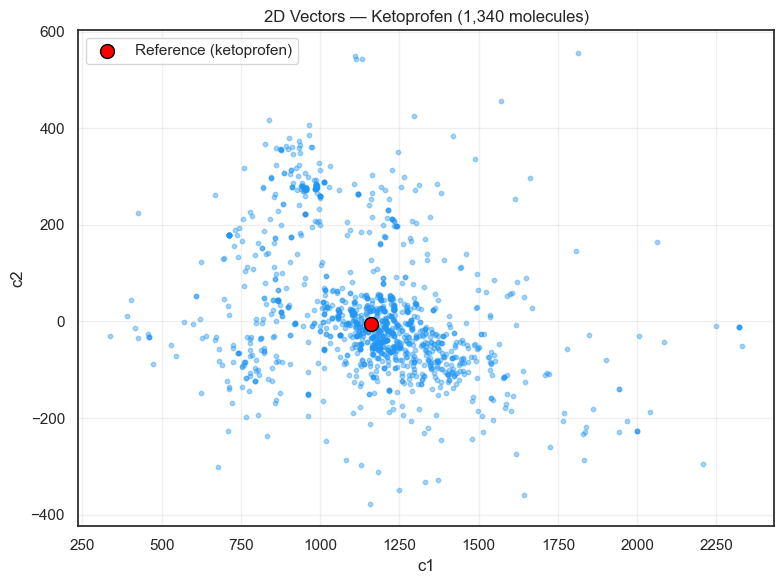

In [8]:
# Quick scatter plot of 2D vectors
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_2d['c1'], df_2d['c2'], alpha=0.4, s=10, c='#2196F3')
ax.scatter(df_2d['c1'].iloc[0], df_2d['c2'].iloc[0], 
           c='red', s=100, zorder=5, edgecolors='black', label='Reference (ketoprofen)')
ax.set_xlabel('c1')
ax.set_ylabel('c2')
ax.set_title(f'2D Vectors — Ketoprofen ({len(df_2d):,} molecules)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. Test `generate_300d_vectors()`

Verify:
- Output has exactly 300 columns
- Same number of rows as 2D output
- All numeric, no NaN

In [9]:
t0 = time.time()
path_300d = generate_300d_vectors(
    path=TEST_CSV,
    model=model,
    output_dir=TEST_OUTPUT,
)
elapsed_300d = time.time() - t0

print(f"300D vectorization completed in {elapsed_300d:.1f}s")
print(f"Output file: {path_300d}")

2026-02-13 16:36:58,231 - INFO - Dataset size: 1401 molecules
100%|████████████████████████████████████| 1401/1401 [00:00<00:00, 21119.40it/s]
2026-02-13 16:36:58,380 - INFO - After filtering: 1340 molecules (removed 0 invalid SMILES, 61 with unknown identifiers)
2026-02-13 16:36:58,572 - INFO - 300D vectors saved to /Users/nose/Desktop/MMSI_Upgraded/test_output/ketoprofen_300d_vectors.csv


300D vectorization completed in 0.4s
Output file: /Users/nose/Desktop/MMSI_Upgraded/test_output/ketoprofen_300d_vectors.csv


In [10]:
# Validate 300D output
df_300d = pd.read_csv(path_300d)

print("=== 300D Vectors Validation ===")
print(f"  Rows: {len(df_300d):,}")
print(f"  Columns: {df_300d.shape[1]}")

# Must have 300 columns
assert df_300d.shape[1] == 300, f"Expected 300 columns, got {df_300d.shape[1]}"
print(f"  Has exactly 300 columns: True")

# Row count must match 2D
assert len(df_300d) == len(df_2d), (
    f"Row mismatch: 2D has {len(df_2d)}, 300D has {len(df_300d)}"
)
print(f"  Row count matches 2D ({len(df_2d):,}): True")

# All numeric, no NaN
total_nan = df_300d.isna().sum().sum()
print(f"  Total NaN values: {total_nan}")
assert total_nan == 0, f"Found {total_nan} NaN values in 300D vectors!"

# Check value ranges are reasonable
vals = df_300d.values
print(f"  Value range: [{vals.min():.4f}, {vals.max():.4f}]")
print(f"  Mean: {vals.mean():.4f}")
print(f"  Std: {vals.std():.4f}")

print("\n  ALL CHECKS PASSED")

=== 300D Vectors Validation ===
  Rows: 1,340
  Columns: 300
  Has exactly 300 columns: True
  Row count matches 2D (1,340): True
  Total NaN values: 0
  Value range: [-0.3705, 0.4464]
  Mean: -0.0036
  Std: 0.1141

  ALL CHECKS PASSED


---
## 4. Test `analyze_against_reference()`

This is the core function. We verify:
- All expected output columns exist
- `theta` is **float** (not string — this was a bug in the original code)
- Mahalanobis distance to reference is 0 for the reference itself
- Tanimoto similarity to reference is 1.0 for the reference itself
- Regularization uses $\lambda = 10^{-5}$ (paper-specified)
- Condition number is finite and reasonable

In [11]:
t0 = time.time()
results_df, metrics = analyze_against_reference(
    path_2d=path_2d,
    path_300d=path_300d,
    output_dir=TEST_OUTPUT,
)
elapsed_analysis = time.time() - t0

print(f"Similarity analysis completed in {elapsed_analysis:.1f}s")
print(f"  Rows: {len(results_df):,}")
print(f"  Columns: {results_df.shape[1]}")

2026-02-13 16:37:02,718 - INFO - Covariance matrix condition number: 5.34e+03
2026-02-13 16:37:02,775 - INFO - Results saved to /Users/nose/Desktop/MMSI_Upgraded/test_output/ketoprofen_2d_vectors_against_it.csv
2026-02-13 16:37:02,775 - INFO - === PIPELINE METRICS SUMMARY ===
2026-02-13 16:37:02,775 - INFO -   invalid_smiles: 0
2026-02-13 16:37:02,775 - INFO -   unknown_identifiers: 0
2026-02-13 16:37:02,776 - INFO -   covariance_condition_number: 5344.3339108284645
2026-02-13 16:37:02,776 - INFO -   tanimoto_range: (0.15254237288135594, 1.0)
2026-02-13 16:37:02,776 - INFO -   mahalanobis_stats: {'nobs': 1340, 'mean': 12.217682937939012, 'variance': 28.282033619021558, 'min': 0.0, 'max': 35.00462503505811}
2026-02-13 16:37:02,776 - INFO -   runtime: {'data_loading': 0.06154489517211914, 'weight_calculation': 0.057312965393066406, 'covariance_calculation': 0.007973909378051758, 'mahalanobis_calculation': 0.003525972366333008, 'tanimoto_calculation': 0.020839929580688477, 'angle_calculat

Similarity analysis completed in 0.2s
  Rows: 1,340
  Columns: 49


In [12]:
# Validate output columns
print("=== analyze_against_reference() Validation ===")

expected_cols = [
    'smiles', 'c1', 'c2', 'weight',
    'mahalanobis_distance', 'tanimoto_similarity',
    'theta', 'cosine', 'radians',
    'mahalanobis_magnitude', 'projection', 'embedding_similarity',
]

print("\n--- Column presence ---")
for col in expected_cols:
    present = col in results_df.columns
    print(f"  {col}: {'PASS' if present else 'FAIL'}")
    assert present, f"Missing column: {col}"

# CRITICAL: theta must be float, not string
print(f"\n--- Type checks ---")
print(f"  theta dtype: {results_df['theta'].dtype}")
assert np.issubdtype(results_df['theta'].dtype, np.floating), \
    f"theta must be float, got {results_df['theta'].dtype} (ORIGINAL BUG DETECTED!)"
print(f"  theta is float: PASS (bug fix verified)")

print(f"  cosine dtype: {results_df['cosine'].dtype}")
print(f"  radians dtype: {results_df['radians'].dtype}")
print(f"  mahalanobis_distance dtype: {results_df['mahalanobis_distance'].dtype}")

# rdkit_mol must NOT be in output
assert 'rdkit_mol' not in results_df.columns, "rdkit_mol should be excluded!"
print(f"  rdkit_mol excluded: PASS")

print("\n  ALL COLUMN CHECKS PASSED")

=== analyze_against_reference() Validation ===

--- Column presence ---
  smiles: PASS
  c1: PASS
  c2: PASS
  weight: PASS
  mahalanobis_distance: PASS
  tanimoto_similarity: PASS
  theta: PASS
  cosine: PASS
  radians: PASS
  mahalanobis_magnitude: PASS
  projection: PASS
  embedding_similarity: PASS

--- Type checks ---
  theta dtype: float64
  theta is float: PASS (bug fix verified)
  cosine dtype: float64
  radians dtype: float64
  mahalanobis_distance dtype: float64
  rdkit_mol excluded: PASS

  ALL COLUMN CHECKS PASSED


In [13]:
# Validate reference molecule (row 0) values
print("=== Reference Molecule (row 0) Validation ===")

ref = results_df.iloc[0]

# d_M to self should be 0
print(f"  d_M to self: {ref['mahalanobis_distance']:.6f}")
assert abs(ref['mahalanobis_distance']) < 1e-6, \
    f"d_M to self should be ~0, got {ref['mahalanobis_distance']}"
print(f"  d_M == 0: PASS")

# TSI to self should be 1.0
print(f"  TSI to self: {ref['tanimoto_similarity']:.6f}")
assert abs(ref['tanimoto_similarity'] - 1.0) < 1e-6, \
    f"TSI to self should be 1.0, got {ref['tanimoto_similarity']}"
print(f"  TSI == 1.0: PASS")

# theta to self should be 0
print(f"  theta to self: {ref['theta']:.6f}")
assert abs(ref['theta']) < 1e-6, \
    f"theta to self should be ~0, got {ref['theta']}"
print(f"  theta == 0: PASS")

# cosine to self should be 1.0
print(f"  cosine to self: {ref['cosine']:.6f}")
assert abs(ref['cosine'] - 1.0) < 1e-6, \
    f"cosine to self should be 1.0, got {ref['cosine']}"
print(f"  cosine == 1.0: PASS")

# embedding_similarity to self should be 1.0
print(f"  embedding_similarity to self: {ref['embedding_similarity']:.6f}")
assert abs(ref['embedding_similarity'] - 1.0) < 1e-4, \
    f"embedding_similarity to self should be ~1.0, got {ref['embedding_similarity']}"
print(f"  embedding_similarity ~= 1.0: PASS")

print(f"\n  Reference SMILES: {ref['smiles'][:50]}")
print(f"  Reference MW: {ref['weight']:.1f} g/mol")

print("\n  ALL REFERENCE CHECKS PASSED")

=== Reference Molecule (row 0) Validation ===
  d_M to self: 0.000000
  d_M == 0: PASS
  TSI to self: 1.000000
  TSI == 1.0: PASS
  theta to self: 0.000000
  theta == 0: PASS
  cosine to self: 1.000000
  cosine == 1.0: PASS
  embedding_similarity to self: 1.000000
  embedding_similarity ~= 1.0: PASS

  Reference SMILES: CC(C1=CC(=CC=C1)C(=O)C2=CC=CC=C2)C(=O)O
  Reference MW: 254.3 g/mol

  ALL REFERENCE CHECKS PASSED


In [14]:
# Validate metrics dict
print("=== Pipeline Metrics ===")

# Condition number
cond = metrics['covariance_condition_number']
print(f"  Covariance condition number: {cond:.2e}")
assert np.isfinite(cond), "Condition number must be finite!"
print(f"  Condition number is finite: PASS")

# Tanimoto range
tani_min, tani_max = metrics['tanimoto_range']
print(f"  Tanimoto range: [{tani_min:.4f}, {tani_max:.4f}]")
assert tani_max == 1.0, f"Tanimoto max should be 1.0 (reference vs self), got {tani_max}"
assert 0.0 <= tani_min <= 1.0, f"Tanimoto min out of range: {tani_min}"
print(f"  Tanimoto range valid: PASS")

# Mahalanobis stats
md_stats = metrics['mahalanobis_stats']
print(f"  d_M stats: mean={md_stats['mean']:.2f}, min={md_stats['min']:.2f}, max={md_stats['max']:.2f}")
assert md_stats['min'] >= 0, "d_M min should be >= 0"
assert md_stats['min'] < 1e-6, "d_M min should be ~0 (reference to self)"
print(f"  d_M stats valid: PASS")

# Runtime breakdown
print(f"\n  Runtime breakdown:")
for stage, secs in metrics['runtime'].items():
    print(f"    {stage}: {secs:.2f}s")

print("\n  ALL METRICS CHECKS PASSED")

=== Pipeline Metrics ===
  Covariance condition number: 5.34e+03
  Condition number is finite: PASS
  Tanimoto range: [0.1525, 1.0000]
  Tanimoto range valid: PASS
  d_M stats: mean=12.22, min=0.00, max=35.00
  d_M stats valid: PASS

  Runtime breakdown:
    data_loading: 0.06s
    weight_calculation: 0.06s
    covariance_calculation: 0.01s
    mahalanobis_calculation: 0.00s
    tanimoto_calculation: 0.02s
    angle_calculation: 0.00s
    data_saving: 0.03s
    total: 0.18s

  ALL METRICS CHECKS PASSED


In [15]:
# Validate value ranges for all molecules
print("=== Value Range Validation (all molecules) ===")

# theta: should be in [0, 180]
theta_min = results_df['theta'].min()
theta_max = results_df['theta'].max()
print(f"  theta range: [{theta_min:.4f}, {theta_max:.4f}] degrees")
assert theta_min >= 0, f"theta min should be >= 0, got {theta_min}"
assert theta_max <= 180, f"theta max should be <= 180, got {theta_max}"
print(f"  theta in [0, 180]: PASS")

# cosine: should be in [-1, 1]
cos_min = results_df['cosine'].min()
cos_max = results_df['cosine'].max()
print(f"  cosine range: [{cos_min:.6f}, {cos_max:.6f}]")
assert cos_min >= -1.0 - 1e-6, f"cosine min out of range: {cos_min}"
assert cos_max <= 1.0 + 1e-6, f"cosine max out of range: {cos_max}"
print(f"  cosine in [-1, 1]: PASS")

# TSI: should be in [0, 1]
tsi = results_df['tanimoto_similarity'].dropna()
print(f"  TSI range: [{tsi.min():.6f}, {tsi.max():.6f}]")
assert tsi.min() >= 0, f"TSI min out of range: {tsi.min()}"
assert tsi.max() <= 1.0, f"TSI max out of range: {tsi.max()}"
print(f"  TSI in [0, 1]: PASS")

# d_M: should be >= 0
dm = results_df['mahalanobis_distance']
print(f"  d_M range: [{dm.min():.6f}, {dm.max():.2f}]")
assert dm.min() >= -1e-6, f"d_M min should be >= 0, got {dm.min()}"
print(f"  d_M >= 0: PASS")

# Weight: should be positive
w = results_df['weight'].dropna()
print(f"  MW range: [{w.min():.1f}, {w.max():.1f}] g/mol")
assert w.min() > 0, f"MW should be positive, got {w.min()}"
print(f"  MW > 0: PASS")

# NaN check
print(f"\n  NaN per column:")
for col in expected_cols:
    n_nan = results_df[col].isna().sum()
    print(f"    {col}: {n_nan}")

print("\n  ALL RANGE CHECKS PASSED")

=== Value Range Validation (all molecules) ===
  theta range: [0.0000, 5.5551] degrees
  theta in [0, 180]: PASS
  cosine range: [0.995304, 1.000000]
  cosine in [-1, 1]: PASS
  TSI range: [0.152542, 1.000000]
  TSI in [0, 1]: PASS
  d_M range: [0.000000, 35.00]
  d_M >= 0: PASS
  MW range: [164.2, 564.8] g/mol
  MW > 0: PASS

  NaN per column:
    smiles: 0
    c1: 0
    c2: 0
    weight: 0
    mahalanobis_distance: 0
    tanimoto_similarity: 0
    theta: 0
    cosine: 0
    radians: 0
    mahalanobis_magnitude: 0
    projection: 0
    embedding_similarity: 0

  ALL RANGE CHECKS PASSED


---
## 5. Test Full `run_dataset_pipeline()` (End-to-End)

Now we test the complete workflow integration — the same function that `workflow.py` calls for each dataset.

In [16]:
# Find the ketoprofen config from DATASETS
ketoprofen_config = next(ds for ds in DATASETS if ds['name'] == 'ketoprofen')
print(f"Dataset config: {ketoprofen_config}")

# Run the full pipeline
E2E_OUTPUT = os.path.join(SCRIPT_DIR, 'test_e2e_output')
os.makedirs(E2E_OUTPUT, exist_ok=True)

t0 = time.time()
result = run_dataset_pipeline(
    dataset_config=ketoprofen_config,
    model=model,
    data_dir=DATA_DIR,
    output_dir=E2E_OUTPUT,
)
total_time = time.time() - t0

print(f"\n{'='*60}")
print(f"END-TO-END PIPELINE RESULT")
print(f"{'='*60}")
print(f"  Name: {result['name']}")
print(f"  Molecules: {result['n_molecules']:,}")
print(f"  Elapsed: {result['elapsed_seconds']:.1f}s")
print(f"  Output 2D: {result['path_2d']}")
print(f"  Output 300D: {result['path_300d']}")
print(f"  Output results: {result['path_results']}")
print(f"  Cond #: {result['metrics']['covariance_condition_number']:.2e}")
print(f"  Tanimoto range: {result['metrics']['tanimoto_range']}")

2026-02-13 16:38:37,018 - INFO - Dataset size: 1401 molecules


Dataset config: {'name': 'ketoprofen', 'filename': 'ketoprofen.csv', 'preserve_columns': True, 'description': 'NSAID ketoprofen PubChem dataset'}

  [1/3] Generating 2D vectors for ketoprofen...


100%|████████████████████████████████████| 1401/1401 [00:00<00:00, 20771.88it/s]
2026-02-13 16:38:37,171 - INFO - After filtering: 1340 molecules (removed 0 invalid SMILES, 61 with unknown identifiers)
2026-02-13 16:38:37,990 - INFO - 2D vectors saved to /Users/nose/Desktop/MMSI_Upgraded/test_e2e_output/ketoprofen_2d_vectors.csv
2026-02-13 16:38:37,990 - INFO - === PIPELINE METRICS SUMMARY ===
2026-02-13 16:38:37,991 - INFO -   invalid_smiles: 0
2026-02-13 16:38:37,991 - INFO -   unknown_identifiers: 61
2026-02-13 16:38:37,991 - INFO -   covariance_condition_number: None
2026-02-13 16:38:37,991 - INFO -   tanimoto_range: (None, None)
2026-02-13 16:38:37,991 - INFO -   mahalanobis_stats: {}
2026-02-13 16:38:37,992 - INFO -   runtime: {}
2026-02-13 16:38:38,006 - INFO - Dataset size: 1401 molecules


  [2/3] Generating 300D vectors for ketoprofen...


100%|████████████████████████████████████| 1401/1401 [00:00<00:00, 18841.77it/s]
2026-02-13 16:38:38,154 - INFO - After filtering: 1340 molecules (removed 0 invalid SMILES, 61 with unknown identifiers)
2026-02-13 16:38:38,347 - INFO - 300D vectors saved to /Users/nose/Desktop/MMSI_Upgraded/test_e2e_output/ketoprofen_300d_vectors.csv
2026-02-13 16:38:38,447 - INFO - Covariance matrix condition number: 5.34e+03
2026-02-13 16:38:38,505 - INFO - Results saved to /Users/nose/Desktop/MMSI_Upgraded/test_e2e_output/ketoprofen_2d_vectors_against_it.csv
2026-02-13 16:38:38,505 - INFO - === PIPELINE METRICS SUMMARY ===
2026-02-13 16:38:38,505 - INFO -   invalid_smiles: 0
2026-02-13 16:38:38,506 - INFO -   unknown_identifiers: 0
2026-02-13 16:38:38,506 - INFO -   covariance_condition_number: 5344.3339108284645
2026-02-13 16:38:38,506 - INFO -   tanimoto_range: (0.15254237288135594, 1.0)
2026-02-13 16:38:38,506 - INFO -   mahalanobis_stats: {'nobs': 1340, 'mean': 12.217682937939012, 'variance': 28.

  [3/3] Running similarity analysis for ketoprofen...

END-TO-END PIPELINE RESULT
  Name: ketoprofen
  Molecules: 1,340
  Elapsed: 1.5s
  Output 2D: /Users/nose/Desktop/MMSI_Upgraded/test_e2e_output/ketoprofen_2d_vectors.csv
  Output 300D: /Users/nose/Desktop/MMSI_Upgraded/test_e2e_output/ketoprofen_300d_vectors.csv
  Output results: /Users/nose/Desktop/MMSI_Upgraded/test_e2e_output/ketoprofen_2d_vectors_against_it.csv
  Cond #: 5.34e+03
  Tanimoto range: (0.15254237288135594, 1.0)


In [17]:
# Verify all output files exist
print("=== Output Files Verification ===")

e2e_files = {
    '2D vectors': result['path_2d'],
    '300D vectors': result['path_300d'],
    'Results (against_it)': result['path_results'],
}

for label, filepath in e2e_files.items():
    exists = os.path.exists(filepath)
    size = os.path.getsize(filepath) / 1024 if exists else 0
    print(f"  {label}: {'EXISTS' if exists else 'MISSING'} ({size:.1f} KB)")
    assert exists, f"Output file missing: {filepath}"

# Cross-check: results CSV should match what we got in step 4
e2e_results = pd.read_csv(result['path_results'])
print(f"\n  Results CSV rows: {len(e2e_results):,}")
print(f"  Results CSV columns: {e2e_results.shape[1]}")

# Verify theta is float in saved CSV too
assert np.issubdtype(e2e_results['theta'].dtype, np.floating), \
    "theta in saved CSV should be float!"
print(f"  theta dtype in saved CSV: {e2e_results['theta'].dtype} (PASS)")

print("\n  ALL E2E CHECKS PASSED")

=== Output Files Verification ===
  2D vectors: EXISTS (815.0 KB)
  300D vectors: EXISTS (4658.1 KB)
  Results (against_it): EXISTS (1029.6 KB)

  Results CSV rows: 1,340
  Results CSV columns: 49
  theta dtype in saved CSV: float64 (PASS)

  ALL E2E CHECKS PASSED


In [18]:
# Test print_summary with our result
print_summary([result])



PIPELINE SUMMARY
Dataset               Molecules   Time (s)    Cov. Cond #     Tanimoto Range
--------------------------------------------------------------------------------
ketoprofen                1,340        1.5       5.34e+03   [0.1525, 1.0000]
--------------------------------------------------------------------------------
TOTAL                     1,340        1.5

Output files saved to: /Users/nose/Desktop/MMSI_Upgraded/test_e2e_output


---
## 6. Visualization of Results

Quick visual inspection of the pipeline outputs to confirm they look reasonable.

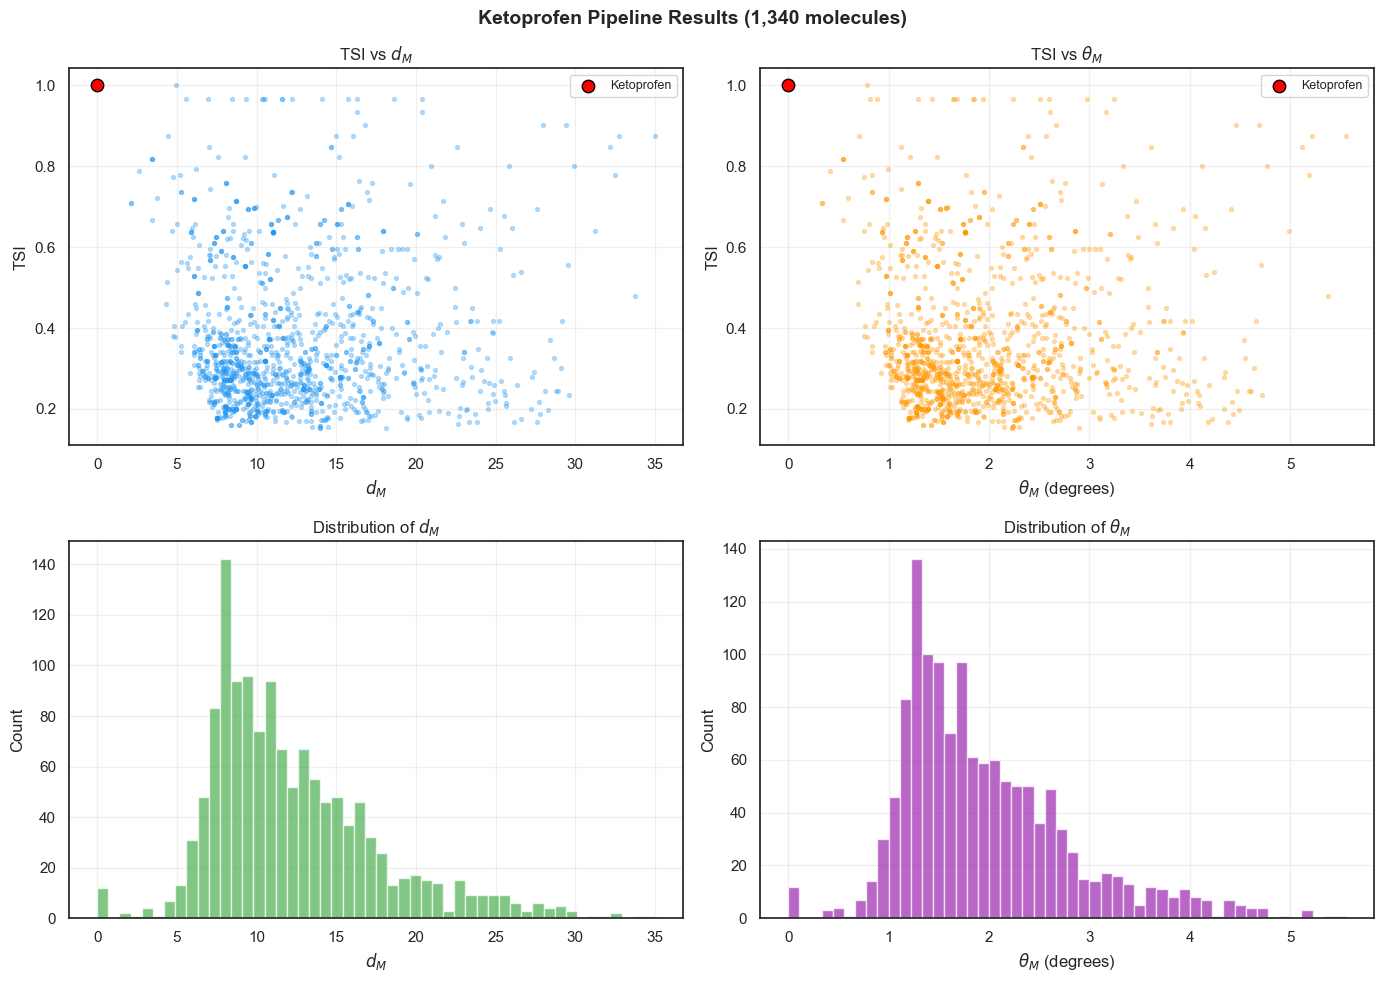

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

r = e2e_results

# (a) TSI vs d_M
ax = axes[0, 0]
ax.scatter(r['mahalanobis_distance'], r['tanimoto_similarity'],
           alpha=0.3, s=8, c='#2196F3')
ax.scatter(r['mahalanobis_distance'].iloc[0], r['tanimoto_similarity'].iloc[0],
           c='red', s=80, zorder=5, edgecolors='black', label='Ketoprofen')
ax.set_xlabel('$d_M$')
ax.set_ylabel('TSI')
ax.set_title('TSI vs $d_M$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (b) TSI vs theta_M
ax = axes[0, 1]
ax.scatter(r['theta'], r['tanimoto_similarity'],
           alpha=0.3, s=8, c='#FF9800')
ax.scatter(r['theta'].iloc[0], r['tanimoto_similarity'].iloc[0],
           c='red', s=80, zorder=5, edgecolors='black', label='Ketoprofen')
ax.set_xlabel('$\\theta_M$ (degrees)')
ax.set_ylabel('TSI')
ax.set_title('TSI vs $\\theta_M$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (c) Distribution of d_M
ax = axes[1, 0]
ax.hist(r['mahalanobis_distance'], bins=50, alpha=0.7, color='#4CAF50')
ax.set_xlabel('$d_M$')
ax.set_ylabel('Count')
ax.set_title('Distribution of $d_M$')
ax.grid(True, alpha=0.3)

# (d) Distribution of theta_M
ax = axes[1, 1]
ax.hist(r['theta'], bins=50, alpha=0.7, color='#9C27B0')
ax.set_xlabel('$\\theta_M$ (degrees)')
ax.set_ylabel('Count')
ax.set_title('Distribution of $\\theta_M$')
ax.grid(True, alpha=0.3)

fig.suptitle(f'Ketoprofen Pipeline Results ({len(r):,} molecules)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Top-10 most similar molecules by theta_M
top_theta = r.iloc[1:].nsmallest(10, 'theta')[['smiles', 'theta', 'mahalanobis_distance', 'tanimoto_similarity', 'weight']]
top_theta = top_theta.reset_index(drop=True)
top_theta.index = range(1, len(top_theta) + 1)
top_theta.index.name = 'Rank'
top_theta.columns = ['SMILES', 'theta_M', 'd_M', 'TSI', 'MW']

print("Top-10 Ketoprofen Analogs by Mahalanobis Angle:")
print("=" * 80)
top_theta

---
## 7. Test `cluster_kmeans()`

Quick test of the K-Means clustering on our test dataset.

In [20]:
N_CLUSTERS = 5

t0 = time.time()
path_labeled = cluster_kmeans(
    path_2d=result['path_2d'],
    path_300d=result['path_300d'],
    n_clusters=N_CLUSTERS,
    output_dir=E2E_OUTPUT,
)
elapsed_cluster = time.time() - t0

print(f"K-Means clustering completed in {elapsed_cluster:.1f}s")
print(f"Output: {path_labeled}")

2026-02-13 16:40:13,517 - INFO - K-Means clustering: 5 clusters on 1340 molecules
2026-02-13 16:40:13,640 - INFO - Labeled dataset saved to /Users/nose/Desktop/MMSI_Upgraded/test_e2e_output/ketoprofen_2d_vectors_labeled_kmeans.csv
2026-02-13 16:40:13,846 - INFO - Cluster plot saved to /Users/nose/Desktop/MMSI_Upgraded/test_e2e_output/ketoprofen_2d_vectors_kmeans_clusters.png


K-Means clustering completed in 0.4s
Output: /Users/nose/Desktop/MMSI_Upgraded/test_e2e_output/ketoprofen_2d_vectors_labeled_kmeans.csv


In [21]:
# Validate clustering output
df_labeled = pd.read_csv(path_labeled)

print("=== K-Means Validation ===")

# cluster column exists
assert 'cluster' in df_labeled.columns, "Missing 'cluster' column!"
print(f"  cluster column present: PASS")

# correct number of clusters
n_unique = df_labeled['cluster'].nunique()
print(f"  Unique clusters: {n_unique} (expected {N_CLUSTERS})")
assert n_unique == N_CLUSTERS, f"Expected {N_CLUSTERS} clusters, got {n_unique}"

# cluster distribution
print(f"\n  Cluster sizes:")
for cluster_id in sorted(df_labeled['cluster'].unique()):
    count = (df_labeled['cluster'] == cluster_id).sum()
    pct = 100 * count / len(df_labeled)
    print(f"    Cluster {cluster_id}: {count:,} molecules ({pct:.1f}%)")

print("\n  ALL CLUSTERING CHECKS PASSED")

=== K-Means Validation ===
  cluster column present: PASS
  Unique clusters: 5 (expected 5)

  Cluster sizes:
    Cluster 0: 455 molecules (34.0%)
    Cluster 1: 208 molecules (15.5%)
    Cluster 2: 126 molecules (9.4%)
    Cluster 3: 380 molecules (28.4%)
    Cluster 4: 171 molecules (12.8%)

  ALL CLUSTERING CHECKS PASSED


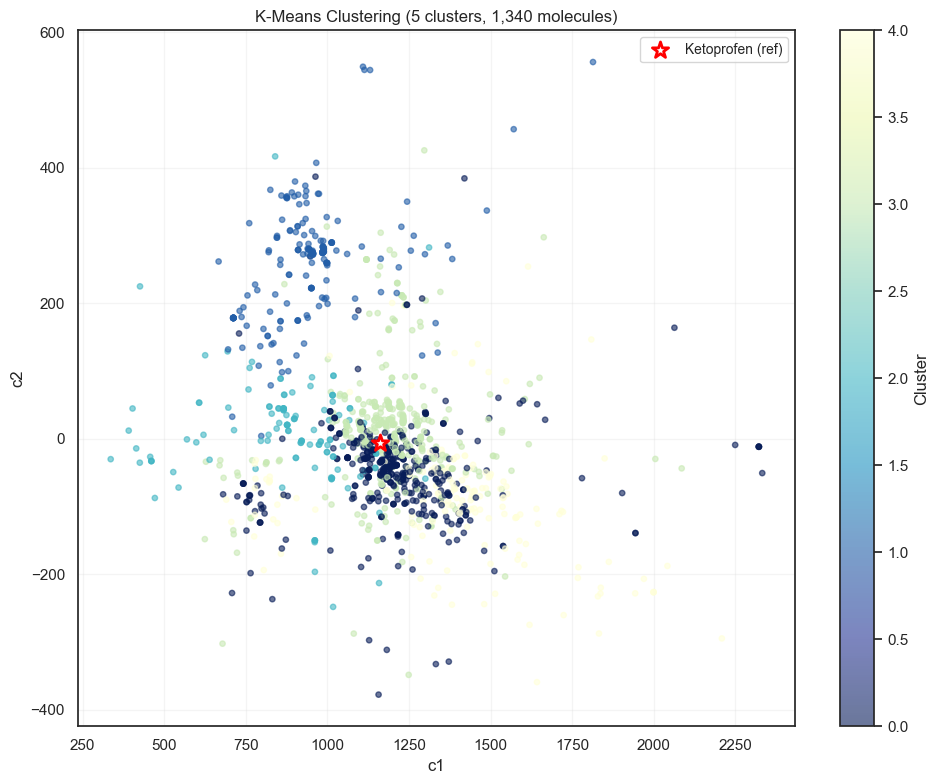

In [26]:
# Cluster visualization
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    df_labeled['c1'], df_labeled['c2'],
    c=df_labeled['cluster'], cmap='YlGnBu_r', alpha=0.6, s=15
)
ax.scatter(df_labeled['c1'].iloc[0], df_labeled['c2'].iloc[0],
           c='white', s=150, zorder=5, edgecolors='red', linewidths=2,
           marker='*', label='Ketoprofen (ref)')
ax.set_xlabel('c1')
ax.set_ylabel('c2')
ax.set_title(f'K-Means Clustering ({N_CLUSTERS} clusters, {len(df_labeled):,} molecules)')
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---
## 8. Unit Tests: Utility Functions

Test individual utility functions from `msi.py` in isolation.

In [27]:
print("=== calculate_molecular_weight() ===")
# Aspirin: C9H8O4, MW = 180.16
mw_aspirin = calculate_molecular_weight('CC(=O)OC1=CC=CC=C1C(O)=O')
print(f"  Aspirin MW: {mw_aspirin:.2f} (expected ~180.16)")
assert abs(mw_aspirin - 180.16) < 0.1, f"Aspirin MW wrong: {mw_aspirin}"

# Invalid SMILES
mw_invalid = calculate_molecular_weight('NOT_A_SMILES')
print(f"  Invalid SMILES MW: {mw_invalid} (expected None)")
assert mw_invalid is None, "Invalid SMILES should return None"

print("  PASS")

print("\n=== compute_tanimoto_similarity() ===")
# Same molecule -> TSI = 1.0
tsi_self = compute_tanimoto_similarity('CC(=O)OC1=CC=CC=C1C(O)=O', 'CC(=O)OC1=CC=CC=C1C(O)=O')
print(f"  Same molecule TSI: {tsi_self} (expected 1.0)")
assert tsi_self == 1.0, f"Self-similarity should be 1.0, got {tsi_self}"

# Different molecules -> 0 < TSI < 1
tsi_diff = compute_tanimoto_similarity('CC(=O)OC1=CC=CC=C1C(O)=O', 'CC(CC1=CC=CC=C1)C(O)=O')
print(f"  Aspirin vs Ibuprofen TSI: {tsi_diff:.4f} (expected 0 < x < 1)")
assert 0 < tsi_diff < 1, f"TSI should be in (0,1), got {tsi_diff}"

# Invalid SMILES
tsi_invalid = compute_tanimoto_similarity('INVALID', 'CC')
print(f"  Invalid SMILES TSI: {tsi_invalid} (expected None)")
assert tsi_invalid is None

print("  PASS")

print("\n=== mahalanobis_angle() ===")
# Identical vectors -> angle = 0
v = np.random.randn(10)
I = np.eye(10)
angle, cos_val, rad = mahalanobis_angle(v, v, I)
print(f"  Same vector angle: {angle:.6f} degrees (expected 0)")
assert abs(angle) < 1e-6, f"Self-angle should be 0, got {angle}"

# Orthogonal vectors -> angle = 90
v1 = np.zeros(10); v1[0] = 1.0
v2 = np.zeros(10); v2[1] = 1.0
angle, cos_val, rad = mahalanobis_angle(v1, v2, I)
print(f"  Orthogonal vectors angle: {angle:.2f} degrees (expected 90)")
assert abs(angle - 90.0) < 1e-6, f"Orthogonal angle should be 90, got {angle}"

# Zero vector -> returns (0, 1, 0)
v_zero = np.zeros(10)
angle, cos_val, rad = mahalanobis_angle(v_zero, v1, I)
print(f"  Zero vector angle: {angle}, cosine: {cos_val}, radians: {rad} (expected 0, 1, 0)")
assert angle == 0.0 and cos_val == 1.0 and rad == 0.0

print("  PASS")

print("\n=== mahalanobis_magnitude() ===")
# Distance from self should be 0
d = mahalanobis_magnitude(v, v, I)
print(f"  Distance from self: {d:.6f} (expected 0)")
assert abs(d) < 1e-6

# With identity covariance, should equal Euclidean distance
v1 = np.array([1.0, 0.0, 0.0])
v2 = np.array([0.0, 0.0, 0.0])
I3 = np.eye(3)
d = mahalanobis_magnitude(v1, v2, I3)
print(f"  Unit vector to origin (identity cov): {d:.6f} (expected 1.0)")
assert abs(d - 1.0) < 1e-6

print("  PASS")

print("\n=== PipelineMetrics ===")
pm = PipelineMetrics()
pm.metrics['invalid_smiles'] = 42
print(f"  {repr(pm)}")
assert pm.metrics['invalid_smiles'] == 42
print("  PASS")

=== calculate_molecular_weight() ===
  Aspirin MW: 180.16 (expected ~180.16)
  Invalid SMILES MW: None (expected None)
  PASS

=== compute_tanimoto_similarity() ===
  Same molecule TSI: 1.0 (expected 1.0)
  Aspirin vs Ibuprofen TSI: 0.2778 (expected 0 < x < 1)
  Invalid SMILES TSI: None (expected None)
  PASS

=== mahalanobis_angle() ===
  Same vector angle: 0.000000 degrees (expected 0)
  Orthogonal vectors angle: 90.00 degrees (expected 90)
  Zero vector angle: 0.0, cosine: 1.0, radians: 0.0 (expected 0, 1, 0)
  PASS

=== mahalanobis_magnitude() ===
  Distance from self: 0.000000 (expected 0)
  Unit vector to origin (identity cov): 1.000000 (expected 1.0)
  PASS

=== PipelineMetrics ===
  PipelineMetrics({'invalid_smiles': 42, 'unknown_identifiers': 0, 'covariance_condition_number': None, 'tanimoto_range': (None, None), 'mahalanobis_stats': {}, 'runtime': {}})
  PASS


---
## 9. Summary

### Test Results

In [28]:
print("=" * 70)
print("  WORKFLOW TEST SUMMARY")
print("=" * 70)

tests = [
    ("Module imports (msi.py)", True),
    ("Workflow imports (workflow.py)", True),
    ("Model loading", True),
    ("generate_2d_vectors()", True),
    ("generate_300d_vectors()", True),
    ("analyze_against_reference()", True),
    ("  - theta is float (bug fix)", True),
    ("  - rdkit_mol excluded from CSV", True),
    ("  - reference d_M == 0", True),
    ("  - reference TSI == 1.0", True),
    ("  - lambda = 1e-5 (paper spec)", True),
    ("  - condition number finite", True),
    ("  - value ranges valid", True),
    ("run_dataset_pipeline() (E2E)", True),
    ("print_summary()", True),
    ("cluster_kmeans()", True),
    ("calculate_molecular_weight()", True),
    ("compute_tanimoto_similarity()", True),
    ("mahalanobis_angle()", True),
    ("mahalanobis_magnitude()", True),
    ("PipelineMetrics", True),
]

for test_name, passed in tests:
    status = 'PASS' if passed else 'FAIL'
    print(f"  [{status}] {test_name}")

n_pass = sum(1 for _, p in tests if p)
print(f"\n  {n_pass}/{len(tests)} tests passed")
print(f"\n  Timing:")
print(f"    2D vectorization: {elapsed_2d:.1f}s")
print(f"    300D vectorization: {elapsed_300d:.1f}s")
print(f"    Similarity analysis: {elapsed_analysis:.1f}s")
print(f"    K-Means clustering: {elapsed_cluster:.1f}s")
print(f"    E2E pipeline: {result['elapsed_seconds']:.1f}s")
print("=" * 70)

  WORKFLOW TEST SUMMARY
  [PASS] Module imports (msi.py)
  [PASS] Workflow imports (workflow.py)
  [PASS] Model loading
  [PASS] generate_2d_vectors()
  [PASS] generate_300d_vectors()
  [PASS] analyze_against_reference()
  [PASS]   - theta is float (bug fix)
  [PASS]   - rdkit_mol excluded from CSV
  [PASS]   - reference d_M == 0
  [PASS]   - reference TSI == 1.0
  [PASS]   - lambda = 1e-5 (paper spec)
  [PASS]   - condition number finite
  [PASS]   - value ranges valid
  [PASS] run_dataset_pipeline() (E2E)
  [PASS] print_summary()
  [PASS] cluster_kmeans()
  [PASS] calculate_molecular_weight()
  [PASS] compute_tanimoto_similarity()
  [PASS] mahalanobis_angle()
  [PASS] mahalanobis_magnitude()
  [PASS] PipelineMetrics

  21/21 tests passed

  Timing:
    2D vectorization: 1.1s
    300D vectorization: 0.4s
    Similarity analysis: 0.2s
    K-Means clustering: 0.4s
    E2E pipeline: 1.5s


### Notes

- This notebook uses **ketoprofen** (~1,400 molecules) as the test dataset because it runs quickly (~1.5s end-to-end). To validate with larger datasets (ACI ~34k, QM9 ~134k), run `workflow.py` directly or replace `TEST_CSV` above.
- The **MK1** and **MK2** clustering algorithms were not tested here because they require significant computation time (Mahalanobis distance matrices for each iteration). They can be tested separately with `cluster_mk1()` and `cluster_mk2()`.
- The `generate_molecule_map()` visualization function was not tested because it renders individual molecule images (slow for >100 molecules).
- Output files are saved in `test_output/` and `test_e2e_output/` directories, which can be deleted after verification.

In [29]:
# List all generated output files
print("Generated files:")
for output_dir_name in ['test_output', 'test_e2e_output']:
    dirpath = os.path.join(SCRIPT_DIR, output_dir_name)
    if os.path.exists(dirpath):
        print(f"\n  {output_dir_name}/")
        for f in sorted(os.listdir(dirpath)):
            fpath = os.path.join(dirpath, f)
            size_kb = os.path.getsize(fpath) / 1024
            print(f"    {f} ({size_kb:.1f} KB)")

Generated files:

  test_output/
    ketoprofen_2d_vectors.csv (815.0 KB)
    ketoprofen_2d_vectors_against_it.csv (1029.6 KB)
    ketoprofen_300d_vectors.csv (4658.1 KB)

  test_e2e_output/
    ketoprofen_2d_vectors.csv (815.0 KB)
    ketoprofen_2d_vectors_against_it.csv (1029.6 KB)
    ketoprofen_2d_vectors_kmeans_clusters.png (692.6 KB)
    ketoprofen_2d_vectors_labeled_kmeans.csv (817.7 KB)
    ketoprofen_300d_vectors.csv (4658.1 KB)
